# **BIG DATA K08 - Week 6 (spark-mllib)**

---

*(Link Kaggle :
https://www.kaggle.com/datasets/thuandao/online-shoppers-purchasing-dataset)*

## Latar Belakang
Perkembangan e-commerce yang pesat membuat perusahaan harus mampu memahami perilaku pengguna secara mendalam. Tidak semua pengunjung yang datang ke sebuah website akan melakukan pembelian. Oleh karena itu, diperlukan analisis data untuk mengetahui faktor-faktor yang mempengaruhi keputusan pembelian pengguna.

Dataset ini merepresentasikan aktivitas pengguna pada sebuah website e-commerce, seperti jumlah halaman yang dikunjungi, durasi kunjungan, jenis pengunjung, hingga apakah pengguna tersebut melakukan pembelian (Revenue). Dengan memanfaatkan teknologi Big Data seperti Apache Spark, analisis dapat dilakukan secara efisien terhadap data dalam skala besar.

Analisis ini bertujuan untuk menggali pola perilaku pengguna serta menemukan insight yang dapat digunakan untuk meningkatkan conversion rate dan strategi bisnis.

## Deskripsi
Dataset yang digunakan berisi informasi aktivitas pengunjung website, dengan atribut utama sebagai berikut:

- Administrative & Informational → jumlah halaman yang dikunjungi
- Durasi (Duration) → waktu yang dihabiskan pengguna
- ProductRelated → aktivitas terkait produk
- BounceRates & ExitRates → perilaku keluar dari website
- PageValues → nilai halaman terhadap potensi transaksi
- SpecialDay → kedekatan dengan hari spesial (promo/event)
- VisitorType → tipe pengunjung (New / Returning)
- Weekend → kunjungan di akhir pekan atau tidak
- Month → bulan kunjungan
- Revenue → apakah terjadi pembelian (target utama)

Dataset ini sangat cocok untuk analisis perilaku pengguna dan prediksi pembelian.

## Konteks Bisnis
Dalam konteks bisnis e-commerce, tujuan utama adalah:

🎯 Meningkatkan Conversion Rate

- Mengubah pengunjung menjadi pembeli adalah prioritas utama
- Dengan mengetahui faktor yang mempengaruhi pembelian,
- perusahaan bisa meningkatkan efektivitas strategi marketing.

🎯 Memahami Perilaku User

Perusahaan perlu mengetahui:

- Kapan user paling sering membeli
- Tipe user mana yang paling potensial
- Aktivitas apa yang menunjukkan niat membeli

🎯 Optimalisasi Strategi Marketing

Insight dari data dapat digunakan untuk:

- Menentukan waktu promo terbaik
- Personalisasi pengalaman pengguna
- Retargeting user yang belum membeli



# Setup & Load Data

In [ ]:
import kagglehub
import os
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, count, countDistinct
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler, OneHotEncoder
from pyspark.ml import Pipeline
from pyspark.ml.classification import LogisticRegression, DecisionTreeClassifier, RandomForestClassifier
from pyspark.ml.regression import LinearRegression, RandomForestRegressor
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator, RegressionEvaluator

# 2. Download dataset
print("Mendownload dataset dari Kaggle...")
folder_path = kagglehub.dataset_download("thuandao/online-shoppers-purchasing-dataset")

# Cari nama file CSV yang ada di dalam folder tersebut
csv_filename = [f for f in os.listdir(folder_path) if f.endswith('.csv')][0]
file_path = os.path.join(folder_path, csv_filename)
print(f"Dataset berhasil didownload di: {file_path}")

# 3. Create SparkSession
spark = SparkSession.builder \
    .appName("OnlineShoppers_MLlib_P6") \
    .getOrCreate()
print("✅ SparkSession created!")

# 4. BACA DATA LANGSUNG MENGGUNAKAN SPARK (Sesuai Aturan Tugas)
# inferSchema=True membuat Spark otomatis mengenali mana kolom angka dan mana kolom teks
spark_df = spark.read.csv(file_path, header=True, inferSchema=True)

# 5. Cek Hasilnya
print(f"Shape: {spark_df.count()} baris, {len(spark_df.columns)} kolom")
spark_df.printSchema()

Mendownload dataset dari Kaggle...
Using Colab cache for faster access to the 'online-shoppers-purchasing-dataset' dataset.
Dataset berhasil didownload di: /kaggle/input/online-shoppers-purchasing-dataset/online_shoppers.csv
✅ SparkSession created!
Shape: 999999 baris, 18 kolom
root
 |-- Administrative: integer (nullable = true)
 |-- Administrative_Duration: double (nullable = true)
 |-- Informational: integer (nullable = true)
 |-- Informational_Duration: double (nullable = true)
 |-- ProductRelated: integer (nullable = true)
 |-- ProductRelated_Duration: double (nullable = true)
 |-- BounceRates: double (nullable = true)
 |-- ExitRates: double (nullable = true)
 |-- PageValues: double (nullable = true)
 |-- SpecialDay: double (nullable = true)
 |-- OperatingSystems: integer (nullable = true)
 |-- Browser: integer (nullable = true)
 |-- Region: integer (nullable = true)
 |-- TrafficType: integer (nullable = true)
 |-- Month: string (nullable = true)
 |-- VisitorType: string (nullable 

# **Ekplorasi Data**



In [ ]:
spark_df.createOrReplaceTempView("ecommerce_data")

print("=" * 80)
print("EKSPLORASI DATA MENGGUNAKAN SPARK")
print("=" * 80)

# 1. Info dasar
print("\n1️⃣ INFORMASI DASAR:")
print(f"Total baris: {spark_df.count()}")
print(f"Total kolom: {len(spark_df.columns)}")

# 2. Tipe data
print("\n2️⃣ TIPE DATA:")
spark_df.printSchema()

# 3. Cek missing values menggunakan Spark SQL
print("\n3️⃣ MISSING VALUES (per kolom):")
missing_summary = spark_df.select(
    [count(when(col(c).isNull(), c)).alias(c) for c in spark_df.columns]
)
missing_summary.show()

# 4. Statistik deskriptif
print("\n4️⃣ STATISTIK DESKRIPTIF:")
spark_df.describe().show()


print("\n5️⃣ DETEKSI OUTLIER (BounceRates) via SPARK SQL:")
# Query SQL untuk ambil Q1 (0.25) dan Q3 (0.75)
quartiles = spark.sql("""
    SELECT
        percentile_approx(BounceRates, 0.25) AS q1,
        percentile_approx(BounceRates, 0.75) AS q3
    FROM ecommerce_data
""").collect()[0]
q1, q3 = quartiles['q1'], quartiles['q3']
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
print(f"Q1: {q1:.4f}, Q3: {q3:.4f}, IQR: {iqr:.4f}")
print(f"Batas Lower: {lower_bound:.4f}, Batas Upper: {upper_bound:.4f}")

# Filter data yang termasuk outlier
outliers_count = spark.sql(f"""
    SELECT COUNT(*) FROM ecommerce_data
    WHERE BounceRates < {lower_bound} OR BounceRates > {upper_bound}
""").collect()[0][0]
print(f"Jumlah Outlier terdeteksi: {outliers_count}")

# 6. Cek duplikat
print("\n6️⃣ DUPLIKAT BARIS:")
duplicate_count = spark_df.count() - spark_df.dropDuplicates().count()
print(f"Jumlah duplikat: {duplicate_count}")

# 7. Analisis target variable (Revenue)
print("\n7️⃣ DISTRIBUSI TARGET VARIABLE (Revenue):")
spark_df.groupBy("Revenue").count().orderBy("Revenue").show()

EKSPLORASI DATA MENGGUNAKAN SPARK

1️⃣ INFORMASI DASAR:
Total baris: 999999
Total kolom: 18

2️⃣ TIPE DATA:
root
 |-- Administrative: integer (nullable = true)
 |-- Administrative_Duration: double (nullable = true)
 |-- Informational: integer (nullable = true)
 |-- Informational_Duration: double (nullable = true)
 |-- ProductRelated: integer (nullable = true)
 |-- ProductRelated_Duration: double (nullable = true)
 |-- BounceRates: double (nullable = true)
 |-- ExitRates: double (nullable = true)
 |-- PageValues: double (nullable = true)
 |-- SpecialDay: double (nullable = true)
 |-- OperatingSystems: integer (nullable = true)
 |-- Browser: integer (nullable = true)
 |-- Region: integer (nullable = true)
 |-- TrafficType: integer (nullable = true)
 |-- Month: string (nullable = true)
 |-- VisitorType: string (nullable = true)
 |-- Weekend: boolean (nullable = true)
 |-- Revenue: boolean (nullable = true)


3️⃣ MISSING VALUES (per kolom):
+--------------+-----------------------+---------

### Bagian ini dikerjakan oleh Rayka Dharma Pranandita (039)

/tmp/ipykernel_31655/1093896516.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=plot_df, x="VisitorType", ax=axes[2, 0], palette="viridis")


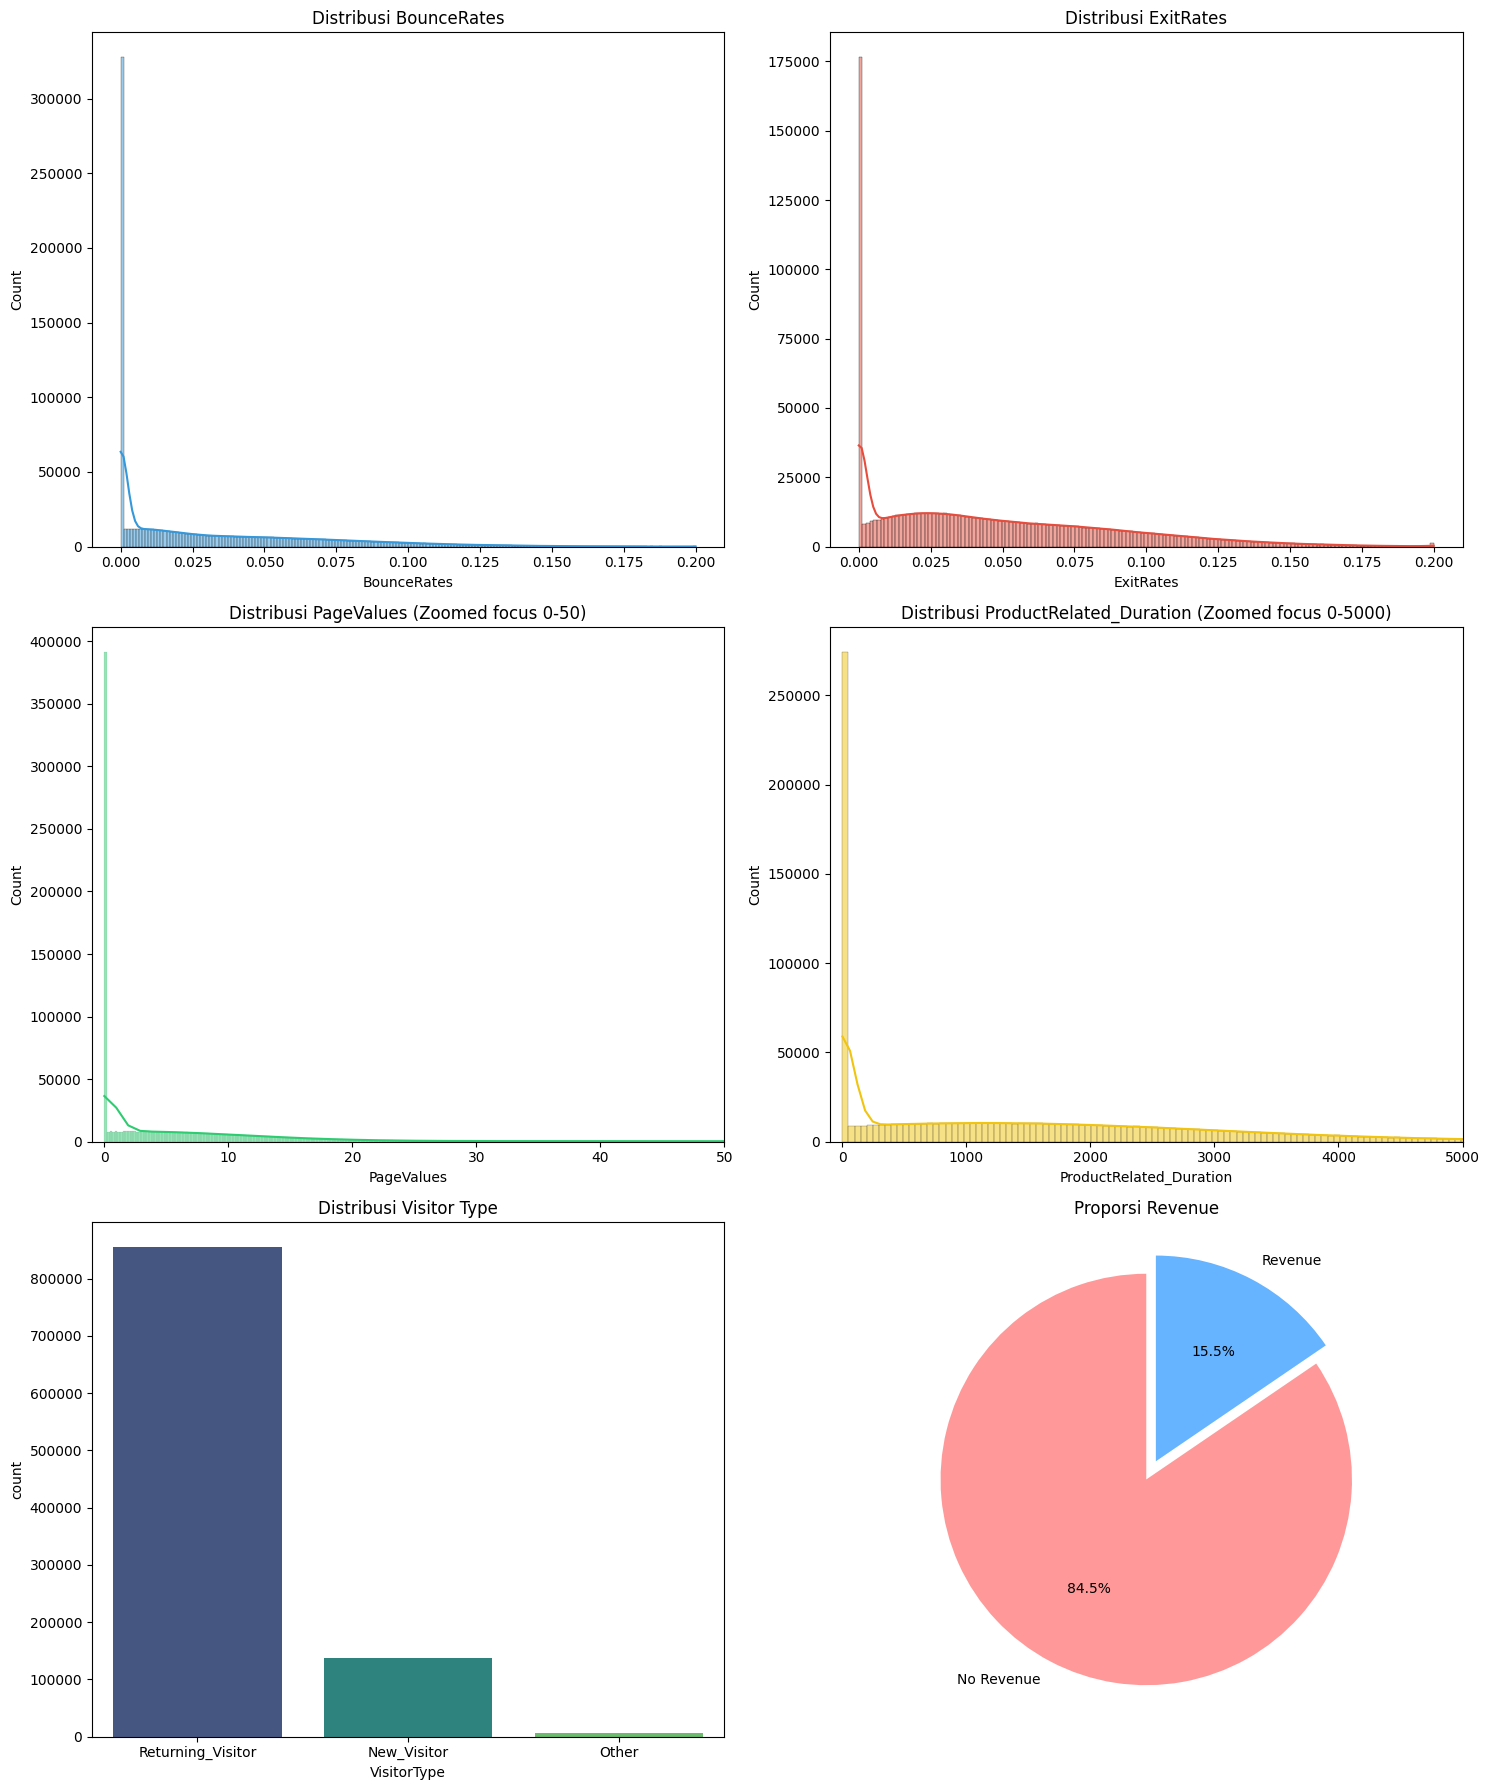

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ambil data
cols = ["BounceRates", "ExitRates", "PageValues", "ProductRelated_Duration", "VisitorType", "Revenue"]
plot_df = spark_df.select(cols).toPandas()

# Setup canvas 3x2
fig, axes = plt.subplots(3, 2, figsize=(15, 18))
colors = ["#3498db", "#e74c3c", "#2ecc71", "#f1c40f"]

# 1. BounceRates (0 - 0.2)
sns.histplot(plot_df["BounceRates"], kde=True, ax=axes[0, 0], color=colors[0])
axes[0, 0].set_title("Distribusi BounceRates")

# 2. ExitRates (0 - 0.2)
sns.histplot(plot_df["ExitRates"], kde=True, ax=axes[0, 1], color=colors[1])
axes[0, 1].set_title("Distribusi ExitRates")

# 3. PageValues (Batasi X sampai 50 agar tidak terlalu gepeng)
sns.histplot(plot_df["PageValues"], kde=True, ax=axes[1, 0], color=colors[2])
axes[1, 0].set_xlim(-1, 50) # Fokus ke area mayoritas data
axes[1, 0].set_title("Distribusi PageValues (Zoomed focus 0-50)")

# 4. ProductRelated_Duration (Batasi X sampai 5000)
sns.histplot(plot_df["ProductRelated_Duration"], kde=True, ax=axes[1, 1], color=colors[3])
axes[1, 1].set_xlim(-100, 5000) # Memotong pencilan ekstrem di kanan
axes[1, 1].set_title("Distribusi ProductRelated_Duration (Zoomed focus 0-5000)")

# 5. VisitorType (Bar Chart)
sns.countplot(data=plot_df, x="VisitorType", ax=axes[2, 0], palette="viridis")
axes[2, 0].set_title("Distribusi Visitor Type")

# 6. Revenue (Pie Chart)
rev_counts = plot_df["Revenue"].value_counts()
axes[2, 1].pie(rev_counts, labels=["No Revenue", "Revenue"], autopct='%1.1f%%',
               startangle=90, colors=["#ff9999","#66b3ff"], explode=(0, 0.1))
axes[2, 1].set_title("Proporsi Revenue")

plt.tight_layout()
plt.show()

# **Analysis**

### Bagian ini dikerjakan oleh Rayka Dharma Pranandita (039)

In [ ]:
from pyspark.sql.functions import col, avg, count, sum, cast, when, round
from pyspark.sql.window import Window
from pyspark.sql import functions as F
spark_df.createOrReplaceTempView("ecommerce_data")

print("\nANALYSIS 1: CONVERSION RATE BY VISITOR TYPE")
conversion_by_visitor = spark_df.groupBy("VisitorType") \
    .agg(
        count("*").alias("total_sessions"),
        avg(col("Revenue").cast("double")).alias("conversion_rate")
    ) \
    .withColumn("conversion_rate", round(col("conversion_rate") * 100, 2)) \
    .orderBy(col("conversion_rate").desc())
conversion_by_visitor.show()

print("\nANALYSIS 2: MONTHLY PERFORMANCE & SPECIAL DAY IMPACT (SPARK SQL)")
special_day_analysis = spark.sql("""
    SELECT
        Month,
        AVG(SpecialDay) as avg_proximity_to_event,
        COUNT(*) as total_sessions,
        ROUND(AVG(CAST(Revenue AS INT)) * 100, 2) as conv_rate_percentage
    FROM ecommerce_data
    GROUP BY Month
    ORDER BY conv_rate_percentage DESC
""")
special_day_analysis.show()

print("\nANALYSIS 3: RANKING VISITOR TYPES BY PRODUCT DURATION PER REGION (WINDOW FUNCTION)")
# 1. Hitung rata-rata durasi per Region dan VisitorType
visitor_region_stats = spark_df.groupBy("Region", "VisitorType") \
    .agg(round(avg("ProductRelated_Duration"), 2).alias("avg_duration"))
# 2. Definisikan Window: Kelompokkan per Region, urutkan durasi dari yang terlama
window_spec = Window.partitionBy("Region").orderBy(col("avg_duration").desc())
# 3. Apply ranking dan ambil urutannya
ranked_visitor_regions = visitor_region_stats.withColumn("rank", F.rank().over(window_spec))
ranked_visitor_regions.show(30)

print("\nANALYSIS 4: BOUNCE RATES VS REVENUE")
bounce_impact = spark_df.groupBy("Revenue") \
    .agg(
        avg("BounceRates").alias("avg_bounce_rate"),
        avg("ExitRates").alias("avg_exit_rate"),
        avg("PageValues").alias("avg_page_value")
    )
bounce_impact.show()


ANALYSIS 1: CONVERSION RATE BY VISITOR TYPE
+-----------------+--------------+---------------+
|      VisitorType|total_sessions|conversion_rate|
+-----------------+--------------+---------------+
|      New_Visitor|        137351|          25.01|
|            Other|          6982|          19.62|
|Returning_Visitor|        855666|          13.91|
+-----------------+--------------+---------------+


ANALYSIS 2: MONTHLY PERFORMANCE & SPECIAL DAY IMPACT (SPARK SQL)
+-----+----------------------+--------------+--------------------+
|Month|avg_proximity_to_event|total_sessions|conv_rate_percentage|
+-----+----------------------+--------------+--------------------+
|  Nov|   0.10669877329577687|        242963|               25.35|
|  Oct|   0.10846698069504894|         44700|               21.15|
|  Sep|   0.11011322767492396|         36059|               19.15|
|  Aug|   0.11108208181531504|         35273|               17.67|
|  Jul|   0.11275796301219931|         35184|               15

# **Data Cleaning & Prepare Data**

In [ ]:
print("\n" * 2)
print("=" * 80)
print("DATA CLEANING & PREPARATION")
print("=" * 80)

# 1. Hapus duplikat
print("\n1️⃣ HAPUS DUPLIKAT:")
spark_df_clean = spark_df.dropDuplicates()
print(f"Baris setelah hapus duplikat: {spark_df_clean.count()}")

# 2. Handle missing values (opsional, karena dataset ini tidak ada yang null)
print("\n2️⃣ MISSING VALUES HANDLING:")
print("Tidak ada missing values — dataset sudah bersih ✅")

# 3. Identifikasi fitur numerik dan kategorik
print("\n3️⃣ IDENTIFIKASI FITUR:")
numeric_cols = [f[0] for f in spark_df_clean.dtypes if f[1] in ['int', 'long', 'double', 'float']]
categorical_cols = [f[0] for f in spark_df_clean.dtypes if f[1] == 'string']
boolean_cols = [f[0] for f in spark_df_clean.dtypes if f[1] == 'boolean']

print(f"Numerik ({len(numeric_cols)}): {numeric_cols}")
print(f"Kategorik ({len(categorical_cols)}): {categorical_cols}")
print(f"Boolean ({len(boolean_cols)}): {boolean_cols}")

# 4. Target variable (Revenue)
print("\n4️⃣ TARGET VARIABLE:")
print("Target: 'Revenue' (klasifikasi: True/False)")

# 5. Features untuk model (exclude Revenue dan Month untuk sekarang)
features_for_model = [col for col in spark_df_clean.columns if col not in ['Revenue', 'Month', 'VisitorType']]
print(f"\nFeatures untuk model ({len(features_for_model)}): {features_for_model}")




DATA CLEANING & PREPARATION

1️⃣ HAPUS DUPLIKAT:
Baris setelah hapus duplikat: 999990

2️⃣ MISSING VALUES HANDLING:
Tidak ada missing values — dataset sudah bersih ✅

3️⃣ IDENTIFIKASI FITUR:
Numerik (14): ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']
Kategorik (2): ['Month', 'VisitorType']
Boolean (2): ['Weekend', 'Revenue']

4️⃣ TARGET VARIABLE:
Target: 'Revenue' (klasifikasi: True/False)

Features untuk model (15): ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Weekend']


# **Feature Engineering**

## **Regresi**    
### Bagian ini dikerjakan oleh Rayka Dharma Pranandita (039)

In [12]:
import time
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler
from pyspark.sql.functions import col

# --- 1. FEATURE ENGINEERING (DERIVED FEATURE) ---
df_reg = spark_df_clean.withColumn(
    "Product_Focus_Ratio",
    col("ProductRelated") / (col("Administrative") + col("Informational") + col("ProductRelated") + 1)
)

df_reg = df_reg.withColumn("Weekend", col("Weekend").cast("integer"))

# --- 2. PRE-PROCESSING STAGES ---
stages = []

# Categorical Handling: StringIndexer Saja
# Justifikasi: Model Tree (DT/RF/GBT) tidak butuh OHE dan lebih efisien dengan ordinal/index.
cat_cols = ['OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend']
for c in cat_cols:
    indexer = StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
    stages += [indexer]

# Vector Assembler
# Menggabungkan fitur numerik, fitur turunan, dan hasil indexing (tanpa _vec)
num_cols = [
    'Administrative_Duration', 'Informational_Duration', 'ProductRelated',
    'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Product_Focus_Ratio'
]
assembler = VectorAssembler(
    inputCols=num_cols + [f"{c}_idx" for c in cat_cols],
    outputCol="features_raw"
)
stages.append(assembler)

# StandardScaler
# Tetap digunakan agar distribusi fitur numerik lebih seimbang
scaler = StandardScaler(inputCol="features_raw", outputCol="features", withMean=False, withStd=True)
stages.append(scaler)

# --- 3. RUN PRE-PROCESSING PIPELINE ---
# Eksekusi dilakukan menggunakan DataFrame API yang lebih optimal (Catalyst Optimizer)
pipeline_prep = Pipeline(stages=stages)
pipeline_prep_model = pipeline_prep.fit(df_reg)
df_final = pipeline_prep_model.transform(df_reg)

# Split data 70/20/10 sesuai standar evaluasi
train_reg, val_reg, test_reg = df_final.select("features", col("ProductRelated_Duration").alias("label")) \
                                      .randomSplit([0.7, 0.2, 0.1], seed=42)

# --- 4. HELPER: TRACE FEATURE NAMES ---
def get_feature_names(pp_model, schema_name="features_raw"):
    # 1. Ambil metadata dari kolom features_raw
    meta = pp_model.transform(df_reg.limit(1)).schema[schema_name].metadata["ml_attr"]["attrs"]

    # 2. Ambil yang 'numeric' DAN yang 'nominal' (hasil StringIndexer)
    numeric_attrs = meta.get("numeric", [])
    nominal_attrs = meta.get("nominal", [])

    # 3. Gabungin keduanya
    all_attrs = numeric_attrs + nominal_attrs

    # 4. Sort berdasarkan index (idx) biar urutannya sesuai dengan vector
    return [x["name"] for x in sorted(all_attrs, key=lambda x: x["idx"])]

# Panggil lagi fungsinya
feature_names = get_feature_names(pipeline_prep_model)
print(f"✅ Pre-processing Done. Total Features: {len(feature_names)}")
print(f"List Fitur: {feature_names}")

✅ Pre-processing Done. Total Features: 14
List Fitur: ['Administrative_Duration', 'Informational_Duration', 'ProductRelated', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Product_Focus_Ratio', 'OperatingSystems_idx', 'Browser_idx', 'Region_idx', 'TrafficType_idx', 'VisitorType_idx', 'Weekend_idx']


In [11]:
print("="*100)
print("DATA SEBELUM FEATURE ENGINEERING (ORIGINAL CLEANED DATA)")
print("="*100)
# Menampilkan 5 baris dari data asli setelah cleaning
spark_df_clean.show(5, truncate=False)

print("\n" + "="*100)
print("DATA SESUDAH FEATURE ENGINEERING (DERIVED FEATURES & CASTING)")
print("="*100)
# Menampilkan 5 baris dari data yang sudah ditambah kolom Product_Focus_Ratio
# dan kolom Weekend yang sudah diubah menjadi integer
df_final.show(5, truncate=False)

DATA SEBELUM FEATURE ENGINEERING (ORIGINAL CLEANED DATA)
+--------------+-----------------------+-------------+----------------------+--------------+-----------------------+--------------------+--------------------+------------------+---------------------+----------------+-------+------+-----------+-----+-----------------+-------+-------+
|Administrative|Administrative_Duration|Informational|Informational_Duration|ProductRelated|ProductRelated_Duration|BounceRates         |ExitRates           |PageValues        |SpecialDay           |OperatingSystems|Browser|Region|TrafficType|Month|VisitorType      |Weekend|Revenue|
+--------------+-----------------------+-------------+----------------------+--------------+-----------------------+--------------------+--------------------+------------------+---------------------+----------------+-------+------+-----------+-----+-----------------+-------+-------+
|3             |65.96205121498184      |1            |41.170889060411824    |54            

## **Klasifikasi**

In [ ]:
print("\n" * 2)
print("=" * 80)
print("FEATURE ENGINEERING DENGAN SPARK MLLIB")
print("=" * 80)

# Define feature engineering stages
print("\n1️⃣ TAHAP 1: ENCODE CATEGORICAL FEATURES")

# StringIndexer untuk kategorik fitur
visitortype_indexer = StringIndexer(
    inputCol="VisitorType",
    outputCol="VisitorType_idx",
    handleInvalid="keep"
)

month_indexer = StringIndexer(
    inputCol="Month",
    outputCol="Month_idx",
    handleInvalid="keep"
)

# Label encoding untuk target (Revenue)
label_indexer = StringIndexer(
    inputCol="Revenue",
    outputCol="label",
    handleInvalid="skip"
)

print("✅ StringIndexer defined untuk: VisitorType, Month, Revenue")

# ========================================
print("\n2️⃣ TAHAP 2: VECTOR ASSEMBLY")

# Gabungkan semua numerik features + indexed categorical
features_to_assemble = [
    'Administrative',
    'Administrative_Duration',
    'Informational',
    'Informational_Duration',
    'ProductRelated',
    'ProductRelated_Duration',
    'BounceRates',
    'ExitRates',
    'PageValues',
    'SpecialDay',
    'OperatingSystems',
    'Browser',
    'Region',
    'TrafficType',
    'Weekend',
    'VisitorType_idx',
    'Month_idx'
]

assembler = VectorAssembler(
    inputCols=features_to_assemble,
    outputCol="features_raw",
    handleInvalid="keep"
)

print(f"✅ VectorAssembler akan menggabungkan {len(features_to_assemble)} fitur")

# ========================================
print("\n3️⃣ TAHAP 3: NORMALISASI (STANDARDIZATION)")

scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withMean=True,
    withStd=True
)

print("✅ StandardScaler akan menormalkan skala fitur")

# ========================================
print("\n4️⃣ BANGUN PIPELINE FEATURE ENGINEERING")

feature_engineering_pipeline = Pipeline(stages=[
    visitortype_indexer,
    month_indexer,
    label_indexer,
    assembler,
    scaler
])

print("✅ Pipeline feature engineering berhasil dibangun")

# Ubah kolom tipe boolean menjadi string
spark_df_clean = spark_df_clean.withColumn("Revenue", col("Revenue").cast("string"))
spark_df_clean = spark_df_clean.withColumn("Weekend", col("Weekend").cast("integer"))

# ========================================
print("\n5️⃣ JALANKAN PIPELINE PADA DATA")

# Fit + transform
df_processed = feature_engineering_pipeline.fit(spark_df_clean).transform(spark_df_clean)

print(f"✅ Pipeline dijalankan pada {df_processed.count()} baris data")

# Verifikasi output
print("\n6️⃣ VERIFIKASI OUTPUT PIPELINE:")
df_processed.select(
    "Administrative",
    "VisitorType",
    "VisitorType_idx",
    "features",
    "label"
).show(5, truncate=False)

print("\nSchema output pipeline:")
df_processed.select("features", "label").printSchema()




FEATURE ENGINEERING DENGAN SPARK MLLIB

1️⃣ TAHAP 1: ENCODE CATEGORICAL FEATURES
✅ StringIndexer defined untuk: VisitorType, Month, Revenue

2️⃣ TAHAP 2: VECTOR ASSEMBLY
✅ VectorAssembler akan menggabungkan 17 fitur

3️⃣ TAHAP 3: NORMALISASI (STANDARDIZATION)
✅ StandardScaler akan menormalkan skala fitur

4️⃣ BANGUN PIPELINE FEATURE ENGINEERING
✅ Pipeline feature engineering berhasil dibangun

5️⃣ JALANKAN PIPELINE PADA DATA
✅ Pipeline dijalankan pada 999990 baris data

6️⃣ VERIFIKASI OUTPUT PIPELINE:
+--------------+-----------------+---------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----+
|Administrative|VisitorType      |VisitorType_idx|features                                 

# **Train-Test Split**



In [ ]:
print("\n" * 2)
print("=" * 80)
print("STEP 4: TRAIN-TEST SPLIT")
print("=" * 80)

# Split data: 70% train, 20% validation, 10% test
train_df, val_df, test_df = df_processed.randomSplit([0.7, 0.2, 0.1], seed=42)

print(f"\n📊 DATA SPLIT:")
print(f"  Training set  : {train_df.count()} baris ({train_df.count()/df_processed.count()*100:.1f}%)")
print(f"  Validation set: {val_df.count()} baris ({val_df.count()/df_processed.count()*100:.1f}%)")
print(f"  Test set      : {test_df.count()} baris ({test_df.count()/df_processed.count()*100:.1f}%)")

# Cek class balance di setiap set
print(f"\n📊 CLASS DISTRIBUTION DALAM SETIAP SET:")

print("\nTraining set:")
train_df.groupBy("label").count().show()

print("Validation set:")
val_df.groupBy("label").count().show()

print("Test set:")
test_df.groupBy("label").count().show()




STEP 4: TRAIN-TEST SPLIT

📊 DATA SPLIT:
  Training set  : 699967 baris (70.0%)
  Validation set: 199749 baris (20.0%)
  Test set      : 100274 baris (10.0%)

📊 CLASS DISTRIBUTION DALAM SETIAP SET:

Training set:
+-----+------+
|label| count|
+-----+------+
|  0.0|591585|
|  1.0|108382|
+-----+------+

Validation set:
+-----+------+
|label| count|
+-----+------+
|  0.0|168949|
|  1.0| 30800|
+-----+------+

Test set:
+-----+-----+
|label|count|
+-----+-----+
|  0.0|84712|
|  1.0|15562|
+-----+-----+



# **Klasifikasi**:     
Klasifikasi digunakan untuk menjawab petanyaan:     
***Bagaimana kita bisa memprediksi secara akurat apakah seorang pengunjung website akan melakukan transaksi (Revenue) berdasarkan pola perilaku mereka (seperti PageValues, BounceRates, dan VisitorType)?***

Intinya: Klasifikasi apakah revenue bernilai True atau False

## **1. Random Forest Classifier**

In [ ]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.classification import RandomForestClassifier
from pyspark.sql.functions import col

print("=" * 80)
print("STEP 5: MODEL 1 - RANDOM FOREST CLASSIFIER")
print("=" * 80)

# A. PERSIAPAN JURI (EVALUATORS)
# Kita siapkan juri sebelum menguji model
print("Menyiapkan evaluator metrik...")
eval_auc = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC")
eval_acc = MulticlassClassificationEvaluator(labelCol="label", metricName="accuracy")
eval_prec = MulticlassClassificationEvaluator(labelCol="label", metricName="weightedPrecision")
eval_rec = MulticlassClassificationEvaluator(labelCol="label", metricName="weightedRecall")
eval_f1 = MulticlassClassificationEvaluator(labelCol="label", metricName="f1")

# B. MEMBANGUN DAN MELATIH MODEL (TRAINING)
print("\n1️⃣ MEMBANGUN DAN MELATIH MODEL RANDOM FOREST...")
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    numTrees=100,
    maxDepth=3,
    seed=42
)

# Latih model menggunakan data training
rf_model = rf.fit(train_df)
print("✅ Training selesai!")

# C. PREDIKSI DATA VALIDATION
print("\n2️⃣ MELAKUKAN PREDIKSI PADA DATA VALIDATION...")
# Uji model menggunakan data validasi
rf_val_predictions = rf_model.transform(val_df)

# D. EVALUASI SEMUA METRIK (Sesuai Syarat Tugas)
print("\n3️⃣ EVALUASI METRIK PADA DATA VALIDATION:")
auc_score = eval_auc.evaluate(rf_val_predictions)
acc_score = eval_acc.evaluate(rf_val_predictions)
prec_score = eval_prec.evaluate(rf_val_predictions)
rec_score = eval_rec.evaluate(rf_val_predictions)
f1_score = eval_f1.evaluate(rf_val_predictions)

print(f" AUC       : {auc_score:.4f}")
print(f" Accuracy  : {acc_score:.4f}")
print(f" Precision : {prec_score:.4f}")
print(f" Recall    : {rec_score:.4f}")
print(f" F1-Score  : {f1_score:.4f}")

# E. CONFUSION MATRIX MANUAL (Syarat Wajib Dosen)
print("\n4️⃣ CONFUSION MATRIX (VALIDATION SET):")

# TP: Benar-benar memprediksi 1 (Beli)
tp = rf_val_predictions.filter((col("label") == 1.0) & (col("prediction") == 1.0)).count()
# FP: Salah memprediksi 1 (Ditebak Beli, aslinya Tidak)
fp = rf_val_predictions.filter((col("label") == 0.0) & (col("prediction") == 1.0)).count()
# TN: Benar-benar memprediksi 0 (Tidak Beli)
tn = rf_val_predictions.filter((col("label") == 0.0) & (col("prediction") == 0.0)).count()
# FN: Salah memprediksi 0 (Ditebak Tidak beli, aslinya Beli)
fn = rf_val_predictions.filter((col("label") == 1.0) & (col("prediction") == 0.0)).count()

print(f"- True Positives  (TP) : {tp} ")
print(f"- False Positives (FP) : {fp} ")
print(f"- True Negatives  (TN) : {tn} ")
print(f"- False Negatives (FN) : {fn} ")

# F. FEATURE IMPORTANCE (Untuk Analisis Bisnis Fase 4)
print("\n5️⃣ TOP 5 FITUR PALING BERPENGARUH (FEATURE IMPORTANCE):")
# Ini daftar nama kolom persis seperti yang kamu buat di Step 2 VectorAssembler
feature_cols = [
    'Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration',
    'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues',
    'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Weekend',
    'VisitorType_idx', 'Month_idx'
]

importances = rf_model.featureImportances.toArray()

# Gabungkan nama kolom dengan nilai bobotnya, lalu urutkan dari terbesar ke terkecil
feature_importance_list = sorted(zip(feature_cols, importances), key=lambda x: x[1], reverse=True)

# Tampilkan 5 teratas
for i, (feat, imp) in enumerate(feature_importance_list[:5]):
    print(f" {i+1}. {feat:25s}: {imp:.4f}")

STEP 5: MODEL 1 - RANDOM FOREST CLASSIFIER
Menyiapkan evaluator metrik...

1️⃣ MEMBANGUN DAN MELATIH MODEL RANDOM FOREST...
✅ Training selesai!

2️⃣ MELAKUKAN PREDIKSI PADA DATA VALIDATION...

3️⃣ EVALUASI METRIK PADA DATA VALIDATION:
 AUC       : 0.9392
 Accuracy  : 0.9248
 Precision : 0.9251
 Recall    : 0.9248
 F1-Score  : 0.9166

4️⃣ CONFUSION MATRIX (VALIDATION SET):
- True Positives  (TP) : 17074 
- False Positives (FP) : 1302 
- True Negatives  (TN) : 167647 
- False Negatives (FN) : 13726 

5️⃣ TOP 5 FITUR PALING BERPENGARUH (FEATURE IMPORTANCE):
 1. PageValues               : 0.5721
 2. ExitRates                : 0.1814
 3. BounceRates              : 0.1139
 4. ProductRelated           : 0.0541
 5. ProductRelated_Duration  : 0.0363


## **2. Gradient Boosted Tree**

In [ ]:
from pyspark.ml.classification import GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.sql.functions import col, when

print("\n" + "="*50)
print("STEP 5: MODEL 2 - GRADIENT BOOSTED TREE")
print("="*50)

# Evaluator
binary_eval = BinaryClassificationEvaluator(labelCol="label")
multi_eval = MulticlassClassificationEvaluator(labelCol="label")
feature_names = assembler.getInputCols()

# Model
print("\n1️⃣ MEMBANGUN DAN MELATIH MODEL GBT...")
gbt = GBTClassifier(labelCol="label", featuresCol="features", maxIter=50)

# Train
gbt_model = gbt.fit(train_df)
print("✅ Training selesai!")

# Predict
print("\n2️⃣ MELAKUKAN PREDIKSI PADA DATA VALIDATION...")
gbt_pred = gbt_model.transform(val_df)

# Metrics
print("\n3️⃣ EVALUASI METRIK PADA DATA VALIDATION:")
auc = binary_eval.evaluate(gbt_pred)
accuracy = multi_eval.setMetricName("accuracy").evaluate(gbt_pred)
precision = multi_eval.setMetricName("weightedPrecision").evaluate(gbt_pred)
recall = multi_eval.setMetricName("weightedRecall").evaluate(gbt_pred)
f1 = multi_eval.setMetricName("f1").evaluate(gbt_pred)

print(f"AUC       : {auc}")
print(f"Accuracy  : {accuracy}")
print(f"Precision : {precision}")
print(f"Recall    : {recall}")
print(f"F1-Score  : {f1}\n")

# Confusion Matrix
print("\n4️⃣ CONFUSION MATRIX (VALIDATION SET):")
cm = gbt_pred.select(
    when((col("prediction") == 1) & (col("label") == 1), 1).otherwise(0).alias("TP"),
    when((col("prediction") == 1) & (col("label") == 0), 1).otherwise(0).alias("FP"),
    when((col("prediction") == 0) & (col("label") == 0), 1).otherwise(0).alias("TN"),
    when((col("prediction") == 0) & (col("label") == 1), 1).otherwise(0).alias("FN")
)

cm_summary = cm.groupBy().sum().collect()[0]

print("Confusion Matrix:")
print(f"TP: {cm_summary['sum(TP)']}")
print(f"FP: {cm_summary['sum(FP)']}")
print(f"TN: {cm_summary['sum(TN)']}")
print(f"FN: {cm_summary['sum(FN)']}")

# Top 5 Features
print("\n💡 TOP 5 INFLUENTIAL FEATURES (GBT):")
gbt_imps = gbt_model.featureImportances.toArray()

top_features = sorted(
    zip(feature_names, gbt_imps),
    key=lambda x: x[1],
    reverse=True
)[:5]

for i, (f, im) in enumerate(top_features):
    print(f"{i+1}. {f:30s}: {im:.4f}")


STEP 5: MODEL 2 - GRADIENT BOOSTED TREE

1️⃣ MEMBANGUN DAN MELATIH MODEL GBT...
✅ Training selesai!

2️⃣ MELAKUKAN PREDIKSI PADA DATA VALIDATION...

3️⃣ EVALUASI METRIK PADA DATA VALIDATION:
AUC       : 0.9639293819206031
Accuracy  : 0.9379020670942032
Precision : 0.9367184434124519
Recall    : 0.9379020670942033
F1-Score  : 0.9336665721624343


4️⃣ CONFUSION MATRIX (VALIDATION SET):
Confusion Matrix:
TP: 20325
FP: 1929
TN: 167020
FN: 10475

💡 TOP 5 INFLUENTIAL FEATURES (GBT):
1. PageValues                    : 0.4603
2. BounceRates                   : 0.1754
3. ExitRates                     : 0.1297
4. SpecialDay                    : 0.0635
5. Month_idx                     : 0.0446


# **3. Logistic Regression**

In [ ]:
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.sql.functions import col, when

print("\n" + "="*50)
print("STEP 5: MODEL 3 - LOGISTIC REGRESSION")
print("="*50)

# Model
print("\n1️⃣ MEMBANGUN DAN MELATIH MODEL Logistic Regression...")
lr = LogisticRegression(labelCol="label", featuresCol="features")

# Train
lr_model = lr.fit(train_df)
print("✅ Training selesai!")

# Predict (validation)
print("\n2️⃣ MELAKUKAN PREDIKSI PADA DATA VALIDATION...")
lr_pred = lr_model.transform(val_df)

# Evaluator
binary_eval = BinaryClassificationEvaluator(labelCol="label")
multi_eval = MulticlassClassificationEvaluator(labelCol="label")

# Metrics
print("\n3️⃣ EVALUASI METRIK PADA DATA VALIDATION:")
auc = binary_eval.evaluate(lr_pred)
accuracy = multi_eval.setMetricName("accuracy").evaluate(lr_pred)
precision = multi_eval.setMetricName("weightedPrecision").evaluate(lr_pred)
recall = multi_eval.setMetricName("weightedRecall").evaluate(lr_pred)
f1 = multi_eval.setMetricName("f1").evaluate(lr_pred)

print(f"AUC       : {auc}")
print(f"Accuracy  : {accuracy}")
print(f"Precision : {precision}")
print(f"Recall    : {recall}")
print(f"F1-Score  : {f1}\n")

# Confusion Matrix (Manual)
print("\n4️⃣ CONFUSION MATRIX (VALIDATION SET):")
cm = lr_pred.select(
    when((col("prediction") == 1) & (col("label") == 1), 1).otherwise(0).alias("TP"),
    when((col("prediction") == 1) & (col("label") == 0), 1).otherwise(0).alias("FP"),
    when((col("prediction") == 0) & (col("label") == 0), 1).otherwise(0).alias("TN"),
    when((col("prediction") == 0) & (col("label") == 1), 1).otherwise(0).alias("FN")
)

cm_summary = cm.groupBy().sum().collect()[0]

print("\nConfusion Matrix:")
print(f"TP: {cm_summary['sum(TP)']}")
print(f"FP: {cm_summary['sum(FP)']}")
print(f"TN: {cm_summary['sum(TN)']}")
print(f"FN: {cm_summary['sum(FN)']}")


STEP 5: MODEL 3 - LOGISTIC REGRESSION

1️⃣ MEMBANGUN DAN MELATIH MODEL Logistic Regression...
✅ Training selesai!

2️⃣ MELAKUKAN PREDIKSI PADA DATA VALIDATION...

3️⃣ EVALUASI METRIK PADA DATA VALIDATION:
AUC       : 0.9051837678979893
Accuracy  : 0.9199295115369789
Precision : 0.9170608428142888
Recall    : 0.9199295115369789
F1-Score  : 0.9125394776760621


4️⃣ CONFUSION MATRIX (VALIDATION SET):

Confusion Matrix:
TP: 17333
FP: 2527
TN: 166422
FN: 13467


# **Regresi**:     
Regresi digunakan untuk menjawab petanyaan:     
***Berapa estimasi waktu yang akan dihabiskan pengunjung di halaman terkait produk (ProductRelated_Duration) berdasarkan karakteristik sesi mereka dan jenis halaman lain yang mereka buka?***

Intinya: Regresi nilai `ProductRelated_Duration`

## **1. Decision Tree Regressor**
### Bagian ini dikerjakan oleh Rayka Dharma Pranandita (039)

In [ ]:
from pyspark.ml.regression import DecisionTreeRegressor
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import RegressionEvaluator
import time

print("\n" + "="*50)
print("DECISION TREE REGRESSOR")
print("="*50)

# Define the RegressionEvaluator
evaluator = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="rmse")

# 1. Caching training data biar CV gak lambat
train_reg.cache()
train_reg.count()

# 2. Inisialisasi Model
dt = DecisionTreeRegressor(featuresCol="features", labelCol="label")

# 3. Build ParamGrid - Tuning kedalaman pohon (maxDepth)
# Note: Semakin dalam, semakin detail tapi rawan overfitting
paramGrid = ParamGridBuilder() \
    .addGrid(dt.maxDepth, [5, 10, 15]) \
    .build()

# 4. Setup CrossValidator
cv = CrossValidator(
    estimator=dt,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator, # Pakai evaluator yang sama (RMSE/MAE/R2)
    numFolds=3
)

# 5. Training (Tuning)
start_time = time.time()
cv_model = cv.fit(train_reg)
dt_duration = time.time() - start_time

# 6. Ekstrak Best Model & Prediksi
best_dt = cv_model.bestModel
dt_predictions = best_dt.transform(val_reg)

# 7. Hitung Trio Metrik
rmse_dt = evaluator.evaluate(dt_predictions, {evaluator.metricName: "rmse"})
mae_dt  = evaluator.evaluate(dt_predictions, {evaluator.metricName: "mae"})
r2_dt   = evaluator.evaluate(dt_predictions, {evaluator.metricName: "r2"})

# 8. Tampilkan Hasil
print("\n📊 HASIL PERBANDINGAN maxDepth (Berdasarkan Avg RMSE):")
for i, (params, metric) in enumerate(zip(paramGrid, cv_model.avgMetrics)):
    print(f" Kombinasi {i+1}: maxDepth={params[dt.maxDepth]} | Avg RMSE: {metric:.4f}")

print("-" * 50)
print(f"BEST MODEL PERFORMANCE (on Validation Set):")
print(f"  - Best maxDepth : {best_dt.getMaxDepth()}")
print(f"  - RMSE          : {rmse_dt:.4f}")
print(f"  - MAE           : {mae_dt:.4f}")
print(f"  - R²            : {r2_dt:.4f}")
print(f"⏱️ Training Time : {dt_duration:.2f} seconds")

# 9. Tracing Feature Importance (Bukan Coefficients)
print("\nTOP 5 INFLUENTIAL FEATURES:")
# Decision Tree menggunakan featureImportances
dt_importances = best_dt.featureImportances.toArray()

for i, (f, imp) in enumerate(sorted(zip(feature_names, dt_importances), key=lambda x: x[1], reverse=True)[:5]):
    print(f" {i+1}. {f:30s}: {imp:.4f}")


DECISION TREE REGRESSOR

📊 HASIL PERBANDINGAN maxDepth (Berdasarkan Avg RMSE):
 Kombinasi 1: maxDepth=5 | Avg RMSE: 800.2399
 Kombinasi 2: maxDepth=10 | Avg RMSE: 784.0928
 Kombinasi 3: maxDepth=15 | Avg RMSE: 861.6699
--------------------------------------------------
BEST MODEL PERFORMANCE (on Validation Set):
  - Best maxDepth : 10
  - RMSE          : 776.1141
  - MAE           : 581.1071
  - R²            : 0.7341
⏱️ Training Time : 1459.98 seconds

TOP 5 INFLUENTIAL FEATURES:
 1. ProductRelated                : 0.9490
 2. Product_Focus_Ratio           : 0.0181
 3. Informational_Duration        : 0.0156
 4. Administrative_Duration       : 0.0154
 5. ExitRates                     : 0.0003


## **2. Random Forest Regressor**
### Bagian ini dikerjakan oleh Rayka Dharma Pranandita (039)

In [ ]:
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
import time

print("\n" + "="*50)
print("RANDOM FOREST REGRESSOR")
print("="*50)

# 1. Caching training data
train_reg.cache()
train_reg.count()

# 2. Inisialisasi Model & Grid
rf = RandomForestRegressor(featuresCol="features", labelCol="label", seed=42)
paramGrid = ParamGridBuilder() \
    .addGrid(rf.numTrees, [20, 50, 100]) \
    .build()

# 3. CrossValidator
cv = CrossValidator(
    estimator=rf,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=3
)

# 4. Training (Tuning)
start_time = time.time()
cv_model = cv.fit(train_reg)
rf_duration = time.time() - start_time

# 5. Ekstrak Best Model & Evaluasi Semua Metrik
best_rf = cv_model.bestModel
rf_predictions = best_rf.transform(val_reg)

# Hitung Trio Metrik
rmse_rf = evaluator.evaluate(rf_predictions, {evaluator.metricName: "rmse"})
mae_rf  = evaluator.evaluate(rf_predictions, {evaluator.metricName: "mae"})
r2_rf   = evaluator.evaluate(rf_predictions, {evaluator.metricName: "r2"})

# 6. Tampilkan Hasil
print("\n📊 HASIL PERBANDINGAN numTrees (Berdasarkan Avg RMSE):")
for i, (params, metric) in enumerate(zip(paramGrid, cv_model.avgMetrics)):
    print(f" Kombinasi {i+1}: numTrees={params[rf.numTrees]:3d} | Avg RMSE: {metric:.4f}")

print("-" * 50)
print(f"🎯 BEST MODEL PERFORMANCE (on Validation Set):")
print(f"   - RMSE : {rmse_rf:.4f} (Rata-rata error jarak)")
print(f"   - MAE  : {mae_rf:.4f}  (Rata-rata error absolut)")
print(f"   - R²   : {r2_rf:.4f}   (Akurasi variansi data)")
print(f"⏱️ Training Time: {rf_duration:.2f} seconds")

# 7. Tracing Feature Importance (Anti-Col_X)
print("\n💡 TOP 5 INFLUENTIAL FEATURES (RF):")
rf_imps = best_rf.featureImportances.toArray()
for i, (f, im) in enumerate(sorted(zip(feature_names, rf_imps), key=lambda x: x[1], reverse=True)[:5]):
    print(f" {i+1}. {f:30s}: {im:.4f}")


RANDOM FOREST REGRESSOR

📊 HASIL PERBANDINGAN numTrees (Berdasarkan Avg RMSE):
 Kombinasi 1: numTrees= 20 | Avg RMSE: 815.8261
 Kombinasi 2: numTrees= 50 | Avg RMSE: 808.5447
 Kombinasi 3: numTrees=100 | Avg RMSE: 809.4062
--------------------------------------------------
🎯 BEST MODEL PERFORMANCE (on Validation Set):
   - RMSE : 807.7916 (Rata-rata error jarak)
   - MAE  : 613.0962  (Rata-rata error absolut)
   - R²   : 0.7120   (Akurasi variansi data)
⏱️ Training Time: 835.54 seconds

💡 TOP 5 INFLUENTIAL FEATURES (RF):
 1. ProductRelated                : 0.6834
 2. Product_Focus_Ratio           : 0.2239
 3. Administrative_Duration       : 0.0459
 4. Informational_Duration        : 0.0303
 5. ExitRates                     : 0.0094


## **3. GBT Regressor**

In [ ]:
from pyspark.ml.regression import GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator
import time

print("\n" * 2)
print("=" * 80)
print("GBT REGRESSOR")
print("=" * 80)

# A. PERSIAPAN DATA UNTUK REGRESI
print("\n1️⃣ Menggunakan data yang sudah disiapkan dari tahap feature engineering regresi.")
train_reg.cache()

print(f" ✅ Training set   : {train_reg.count()} rows")
print(f" ✅ Validation set : {val_reg.count()} rows")
print(f" ✅ Test set       : {test_reg.count()} rows")

# --- B. MODEL BUILDING & TRAINING ---
print("\n2️⃣ TRAINING GBT REGRESSOR...")

gbt = GBTRegressor(
    featuresCol="features",
    labelCol="label",
    maxIter=10,
    maxDepth=5,
    seed=42
)

start_time = time.time()
gbt_model = gbt.fit(train_reg)
duration = time.time() - start_time

print(f" ✅ Training GBT selesai dalam {duration:.2f} detik!")

# --- C. PREDICTION & EVALUATION (ON TEST SET) ---
print("\n3️⃣ EVALUATING PERFORMANCE ON TEST SET...")

gbt_predictions = gbt_model.transform(test_reg)

evaluator = RegressionEvaluator(labelCol="label", predictionCol="prediction")

metrics = {
    "RMSE": evaluator.evaluate(gbt_predictions, {evaluator.metricName: "rmse"}),
    "MAE":  evaluator.evaluate(gbt_predictions, {evaluator.metricName: "mae"}),
    "R2":   evaluator.evaluate(gbt_predictions, {evaluator.metricName: "r2"})
}

print("-" * 50)
for metric, value in metrics.items():
    print(f" 🎯 {metric:5} : {value:.4f}")
print("-" * 50)

# --- D. FEATURE IMPORTANCE ---
print("\n4️⃣ TOP 5 INFLUENTIAL FEATURES (GBT):")
importances_gbt = gbt_model.featureImportances.toArray()
feat_list = sorted(zip(feature_names, importances_gbt), key=lambda x: x[1], reverse=True)

for i, (feat, imp) in enumerate(feat_list[:5]):
    print(f" {i+1}. {feat:25s}: {imp:.4f}")




GBT REGRESSOR

1️⃣ Menggunakan data yang sudah disiapkan dari tahap feature engineering regresi.
 ✅ Training set   : 700067 rows
 ✅ Validation set : 199749 rows
 ✅ Test set       : 100274 rows

2️⃣ TRAINING GBT REGRESSOR...
 ✅ Training GBT selesai dalam 206.59 detik!

3️⃣ EVALUATING PERFORMANCE ON TEST SET...
--------------------------------------------------
 🎯 RMSE  : 781.3499
 🎯 MAE   : 583.2345
 🎯 R2    : 0.7325
--------------------------------------------------

4️⃣ TOP 5 INFLUENTIAL FEATURES (GBT):
 1. ProductRelated           : 0.8813
 2. Administrative_Duration  : 0.0420
 3. Product_Focus_Ratio      : 0.0392
 4. Informational_Duration   : 0.0361
 5. PageValues               : 0.0008


Berdasarkan prediksi model GBT Regressor, rata-rata jarak error antara prediksi dengan data sebenarnya adalah 583.2.. detik dengan nilai R2nya 0.7325 (semakin dekat dengan satu, semakin baik dalam memprediksi data).

Bisa dilihat sendiri di cell bawah untuk perbandingan antara data sebenarnya dengan hasil dari model prediksi.

In [ ]:
print("\nEstimasi ProductRelated_Duration (Prediction) dari GBT Regressor:")
gbt_predictions.select("label", "prediction").show(5)


Estimasi ProductRelated_Duration (Prediction) dari GBT Regressor:
+------------------+------------------+
|             label|        prediction|
+------------------+------------------+
|               0.0| 164.9239110475183|
|1035.7215442977867|2230.0565842976785|
|140.34901080346697| 652.6715767898033|
| 3215.022285876953|2814.0217447702057|
|498.52234107242157|1017.7289142076862|
+------------------+------------------+
only showing top 5 rows
